## Modelo de RL para optimización de trayectorias

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.logger import configure
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback

import os

### Potenciales y gradientes para entrenar y evaluar la particula  

In [27]:
# Gaussianas 
def gaussianas_gradiente(n=3):
    '''
    Funcion que devuelve funciones de potencial con n gaussianas y sus gradientes
    '''
    centers = np.random.uniform(0, 1, size=(n, 2))
    amps = np.random.uniform(0.5, 1.5, size=n)
    sigmas = np.random.uniform(0.05, 0.15, size=n)

    def V(x, y):
        dx = x - centers[:,0]
        dy = y - centers[:,1]
        r2 = dx*dx + dy*dy
        return -np.sum(amps * np.exp(-r2/(2*sigmas**2)))

    def gradV(x, y):
        dx = x - centers[:,0]
        dy = y - centers[:,1]
        r2 = dx*dx + dy*dy

        exp_term = np.exp(-r2/(2*sigmas**2))
        coeff = amps * exp_term / (sigmas**2)

        gx = np.sum(coeff * dx)
        gy = np.sum(coeff * dy)

        grad = np.array([gx, gy], dtype=np.float32)
        return grad / (np.linalg.norm(grad) + 1e-8)

    return V, gradV


# Seno/coseno 
def sin_cos_grad():
    '''
    Funcion equivalente con senos y cosenos
    '''
    def V(x, y):
        return np.sin(3*x)*np.cos(3*y)

    def gradV(x, y):
        gx = 3*np.cos(3*x)*np.cos(3*y)
        gy = -3*np.sin(3*x)*np.sin(3*y)
        grad = np.array([gx, gy], dtype=np.float32)
        return grad / (np.linalg.norm(grad) + 1e-8)

    return V, gradV


# sampler 
def sample_potential():
    '''
    Funcion que elige un potencial aleatorio para pasar al entorno
    '''
    if np.random.rand() < 0.5:
        return gaussianas_gradiente()
    else:
        return sin_cos_grad()
    




In [ ]:
# Potenciales no vistos para evaluar en el test
def V_test(x, y):
    return (
        0.4*np.sin(5*x) * np.cos(4*y)
        + 0.3*np.sin(2*x + y)
        + np.exp(-((x-0.2)**2 + (y-0.8)**2)/0.01)
        - 1.2*np.exp(-((x-0.7)**2 + (y-0.3)**2)/0.02)
    )

def grad_test(x, y):
    gx = (
        0.4*5*np.cos(5*x)*np.cos(4*y)
        + 0.3*2*np.cos(2*x + y)
        + ((x-0.2)/0.01)*np.exp(-((x-0.2)**2 + (y-0.8)**2)/0.01)
        - 1.2*((x-0.7)/0.02)*np.exp(-((x-0.7)**2 + (y-0.3)**2)/0.02)
    )

    gy = (
        -0.4*4*np.sin(5*x)*np.sin(4*y)
        + 0.3*np.cos(2*x + y)
        + ((y-0.8)/0.01)*np.exp(-((x-0.2)**2 + (y-0.8)**2)/0.01)
        - 1.2*((y-0.3)/0.02)*np.exp(-((x-0.7)**2 + (y-0.3)**2)/0.02)
    )

    grad = np.array([gx, gy], dtype=np.float32)
    return grad 




## Entornos de la particula
### Primero el train y despues un entono para el test 

In [ ]:

class FastGradEnv_v0(gym.Env):
    def __init__(self, max_steps=250, weights = None):
        super().__init__()

        # Parametros del modelo
        self.max_steps = max_steps
        self.dt = 0.02
        self.speed = 0.25

        self.energy = 0.0
        self.path_length = 0.0

        # Espacio de acciones, elige un valor entre -1 y 1 que sera el angulo de movimiento en radianes
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)

        ## Espacio de observación (estado del entorno)
        # Vector de 7 componentes normalizadas que describen el sistema:
        #   [0] x        - posición en x (normalizada en [0, 1])
        #   [1] y        - posición en y (normalizada en [0, 1])
        #   [2] vx       - velocidad en x (en [-1, 1])
        #   [3] vy       - velocidad en y (en [-1, 1])
        #   [4] V        - potencial local (en [-2, 2])
        #   [5] dx_goal  - componente x de la dirección hacia el objetivo (en [-1, 1])
        #   [6] dy_goal  - componente y de la dirección hacia el objetivo (en [-1, 1])
        self.observation_space = spaces.Box(
            low=np.array([0,0,-1,-1,-2,-1,-1]),
            high=np.array([1,1,1,1,2,1,1]),
            dtype=np.float32
        )

        # pesos por defecto que pueden ser modificados o pasados como parametros
        # progress sac1 : 8.5
        # sac v1: progress 9.5
        # self.weights = weights or {
        #     "progress": 8.5,
        #     "align": 1.2,
        #     "slope": 0.2,
        #     "potential": 0.05,
        #     "step": 0.01
        # }

        self.weights = weights or {
            "progress": 5,
            "align": 1.5,
            "slope": 0.3,
            "potential": 0.4,
            "step": 0.01
        }


    # Funcion de reset que elige un potencial y posiciones de goal e inicio aleatorios 
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.V_fn, self.grad_fn = sample_potential()

        # Puntos aleatorios, que no se encuentren exactamente en el borde 
        self.pos = self.np_random.uniform(0.05,0.95,2).astype(np.float32)
        self.goal = self.np_random.uniform(0.05,0.95,2).astype(np.float32)

        self.steps = 0
        return self._obs(), {}

    def _obs(self):
        V = np.clip(self.V_fn(self.pos[0], self.pos[1]), -2, 2)
        grad = self.grad_fn(self.pos[0], self.pos[1])

        return np.concatenate([
            self.pos,
            self.goal - self.pos,
            [V],
            grad
        ]).astype(np.float32)

    def step(self, action):
        theta = float(action[0] * np.pi)
        direction = np.array([np.cos(theta), np.sin(theta)], dtype=np.float32)

        prev_pos = self.pos.copy()
        self.pos += self.speed * direction * self.dt
        self.steps += 1

        dist = np.linalg.norm(self.goal - self.pos)
        prev_dist = np.linalg.norm(self.goal - prev_pos)

        # señales
        r_progress = prev_dist - dist
        r_align = np.dot(direction, (self.goal-self.pos)/(dist+1e-8))

        V = np.clip(self.V_fn(self.pos[0], self.pos[1]), -2, 2)
        grad = self.grad_fn(self.pos[0], self.pos[1])

        # Actualizamos las metricas de longitud y energia

        self.energy += V
        self.path_length += self.speed * self.dt

        r_slope = -np.dot(direction, grad)

        w = self.weights

        reward = (
            w["progress"] * r_progress +
            w["align"] * r_align +
            w["slope"] * r_slope -
            w["potential"] * V -
            w["step"]
        )


        terminated = dist < 0.02
        if terminated:
            reward += 20

        truncated = self.steps >= self.max_steps


        # Metricas del modelo
        info = {}

        direct_dist = np.linalg.norm(self.goal - prev_pos)
        efficiency = direct_dist / (self.path_length + 1e-8)

        if terminated or truncated:
            info = {
                "energy": self.energy,
                "success": float(terminated),
                "efficiency": efficiency
            }

        return self._obs(), reward, terminated, truncated, info


In [ ]:
class FastGradEnv(gym.Env):
    def __init__(self, max_steps=250, weights=None):
        super().__init__()

        # Parametros del sistema
        self.max_steps = max_steps
        self.dt = 0.02
        self.speed = 0.25

        self.energy = 0.0
        self.path_length = 0.0
        self.start_pos = np.zeros(2)

        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)


        # Lo que devuelve obs [x, y, dx_goal, dy_goal, V, gx, gy]:
        #   [0] x        - posición en x          (en [0, 1])
        #   [1] y        - posición en y          (en [0, 1])
        #   [2] dx_goal  - delta x hacia el goal  (en [-1, 1])
        #   [3] dy_goal  - delta y hacia el goal  (en [-1, 1])
        #   [4] V        - potencial local         (en [-2, 2])
        #   [5] gx       - gradiente en x          (en [-1, 1])
        #   [6] gy       - gradiente en y          (en [-1, 1])
        self.observation_space = spaces.Box(
            low=np.array( [0.0,  0.0,  -1.0, -1.0, -2.0, -1.0, -1.0], dtype=np.float32),
            high=np.array([1.0,  1.0,   1.0,  1.0,  2.0,  1.0,  1.0], dtype=np.float32),
            dtype=np.float32
        )


        self.weights = weights or {
            "progress": 5,
            "align": 1.5,
            "slope": 0.3,
            "potential": 0.4,
            "step": 0.01
        }

    # Funcion de reinicio, elige un nuevo potencial, posiciones y goal aleatorios
    # evita exactamente situarsse en el borde de la caja 
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.V_fn, self.grad_fn = sample_potential()

        self.pos  = self.np_random.uniform(0.05, 0.95, 2).astype(np.float32)
        self.goal = self.np_random.uniform(0.05, 0.95, 2).astype(np.float32)

        # Almacenamos la posicion inicial
        self.start_pos = self.pos.copy()

        self.steps = 0


        self.energy      = 0.0
        self.path_length = 0.0

        return self._obs(), {}

    def _obs(self):
        V    = float(np.clip(self.V_fn(self.pos[0], self.pos[1]), -2, 2))
        grad = self.grad_fn(self.pos[0], self.pos[1])

        # Normalizar el vector dirección al goal para que quede en [-1, 1]
        delta     = self.goal - self.pos
        dist      = np.linalg.norm(delta) + 1e-8
        dir_goal  = (delta / dist).astype(np.float32)

        # Normalizar gradiente a [-1, 1] para respetar observation_space
        grad_norm = grad / (np.linalg.norm(grad) + 1e-8)

        return np.concatenate([
            self.pos,       # [0, 1]
            dir_goal,       # [-1, 1] 
            [V],            # [-2, 2]
            grad_norm       # [-1, 1]
        ]).astype(np.float32)

    def step(self, action):
        # El agente elige un angulo y se mueve en esa direccion
        # es necesario action[0] porque esta definido como un vector
        theta     = float(action[0] * np.pi)
        direction = np.array([np.cos(theta), np.sin(theta)], dtype=np.float32)

        prev_pos  = self.pos.copy()

        # Actualizamos la posicion
        self.pos  = prev_pos + self.speed * direction * self.dt
        self.steps += 1

        # Distancia a la meta y distancia previa
        dist      = np.linalg.norm(self.goal - self.pos)
        prev_dist = np.linalg.norm(self.goal - prev_pos)

        # Calculamos el progreso
        r_progress = prev_dist - dist

        # Comprobar la direccion y alineamiento. Usamos prev porque ya hemos actualizado posiciones 
        goal_dir   = (self.goal - prev_pos) / (prev_dist + 1e-8)
        r_align    = float(np.dot(direction, goal_dir))

        V    = float(np.clip(self.V_fn(self.pos[0], self.pos[1]), -2, 2))
        grad = self.grad_fn(self.pos[0], self.pos[1])

        r_slope = float(-np.dot(direction, grad))

        # Añadimos la energia y longitud del paso 
        self.energy      += V
        self.path_length += self.speed * self.dt


        # Funcion de reward ajustada con los pesos proporcionados o por defecto
        w = self.weights
        reward = (
              w["progress"]  * r_progress
            + w["align"]     * r_align
            + w["slope"]     * r_slope
            - w["potential"] * V
            - w["step"]
        )

        # Comprobamos si esta fuera y penalizamos 
        out_lim = np.any((self.pos < 0.0) | (self.pos > 1.0))
        if out_lim:
            reward -= 2.0

        # Comprobamos si llega al destino y recompensamos
        terminated = dist < 0.02
        if terminated:
            reward += 20.0

        # Comprobamos si alcanza el limite de pasos 
        truncated = self.steps >= self.max_steps

        info = {}
        if terminated or truncated:
            direct_dist = np.linalg.norm(self.goal - self.start_pos)
            efficiency  = direct_dist / (self.path_length + 1e-8)
            info = {
                "energy":     self.energy,
                "success":    float(terminated),
                "efficiency": efficiency
            }

        return self._obs(), reward, terminated, truncated, info

In [ ]:
# Super clase que hereda de la clase anterior pero usa un potencial fijo para el test
class TestEnv(FastGradEnv):
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.V_fn = V_test
        self.grad_fn = grad_test

        # Evita casos de inicio demasiado cercano
        while True:
            self.pos = self.np_random.uniform(0,1,2)
            self.goal = self.np_random.uniform(0,1,2)
            if np.linalg.norm(self.goal - self.pos) < 0.7:
                break

        return self._obs(), {}

## Función para evaluar las distintas metricas
### Se compara con la trayectoria en línea recta
### Se incluye un histograma de comparación de las energias

In [ ]:
def evaluate2(model, env, n_episodes=20, plot_hist=True):
    '''Funcion que evalua al modelo. El modelo intenta llegar al objetivo n_episodes veces
    se calcula el porcentaje de exito de llegada, la longitud de la trayectoria y energia consumida. 
    Compara respecto a una trayectoria lineal'''
    rewards, lengths, energies, successes, effs = [], [], [], [], []
    linear_energies = []

    for _ in range(n_episodes):
        obs,_ = env.reset()
        start = env.pos.copy()
        goal = env.goal.copy()

        traj = [start.copy()]
        total_r = 0
        energy = 0

        done = False
        term = False

        while not done:
            action,_ = model.predict(obs.reshape(1, -1), deterministic=True)
            action = action[0]

            obs,r,term,trunc,_ = env.step(action)

            total_r += r
            energy += env.V_fn(env.pos[0], env.pos[1])

            traj.append(env.pos.copy())
            done = term or trunc

        traj = np.array(traj)

        # métricas RL
        path_length = np.sum(np.linalg.norm(np.diff(traj, axis=0), axis=1))
        direct_dist = np.linalg.norm(start - goal)

        # trayectoria lineal
        n_points = len(traj)
        xs = np.linspace(start[0], goal[0], n_points)
        ys = np.linspace(start[1], goal[1], n_points)

        energy_lin = 0
        for x, y in zip(xs, ys):
            energy_lin += env.V_fn(x, y)

        # guardar
        rewards.append(total_r)
        lengths.append(len(traj))
        energies.append(energy)
        linear_energies.append(energy_lin)

        successes.append(float(term))
        effs.append(direct_dist / (path_length + 1e-8))

    # ===== HISTOGRAMA =====
    if plot_hist:
        plt.figure()
        plt.hist(ratios, bins=25)
        plt.axvline(np.mean(ratios), linestyle="--")
        plt.xlabel("Energy ratio (RL / lineal)")
        plt.ylabel("Frecuencia")
        plt.title("Distribución de eficiencia energética")
        plt.show()

    return {
        "reward": float(np.mean(rewards)),
        "success": float(np.mean(successes)),
        "length": float(np.mean(lengths)),
        "energy_rl": float(np.mean(energies)),
        "energy_linear": float(np.mean(linear_energies)),
        "energy_ratio": float(np.mean(energies)/np.mean(energy_lin)),
        "efficiency": float(np.mean(effs))
    }

## Callback y entrenamiento

In [32]:
# Añadimos un 
class MetricsCallback(BaseCallback):
    def __init__(self, eval_freq=50000):
        super().__init__()
        self.eval_freq = eval_freq

    def _on_step(self):
        if self.num_timesteps % self.eval_freq != 0:
            return True

        res = evaluate2(self.model, TestEnv(), n_episodes=30)
        print(res)

        return True


metrics_cb = MetricsCallback(eval_freq=50000)

# Almacenado de las metricas de entrenamiento
log_dir = "./logs/sac_run/"
os.makedirs(log_dir, exist_ok=True)

# logger = configure(log_dir, ["tensorboard"])


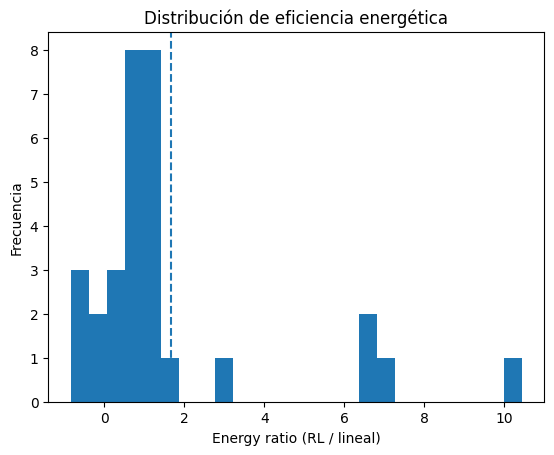

{'reward': 29.610867872631264, 'success': 0.4, 'length': 187.6, 'energy_rl': 31.546301092987573, 'energy_linear': 17.905790266495806, 'energy_ratio': 1.670578011046773, 'efficiency': 0.5364703259787312}


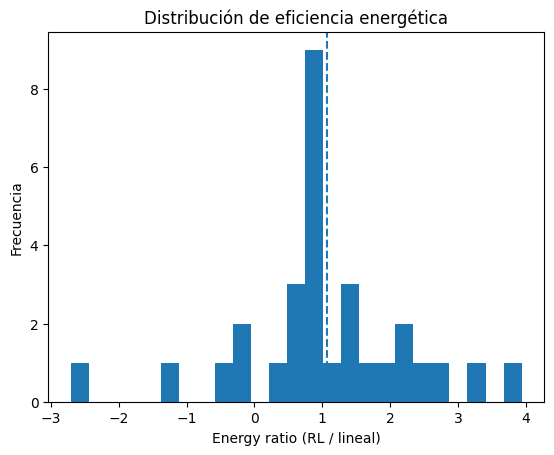

{'reward': 34.640588418988116, 'success': 0.36666666666666664, 'length': 189.63333333333333, 'energy_rl': 34.18334450225447, 'energy_linear': 15.303720014036486, 'energy_ratio': 1.0634024800598807, 'efficiency': 0.5556799317224858}


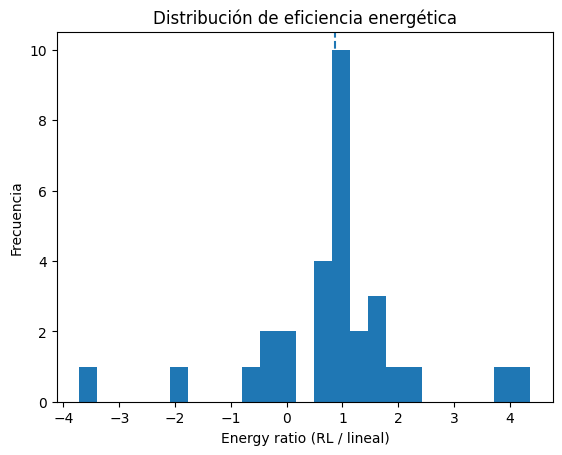

{'reward': 17.842280137986698, 'success': 0.16666666666666666, 'length': 224.5, 'energy_rl': 47.43630766333516, 'energy_linear': 27.076437571832813, 'energy_ratio': 0.8690294414184648, 'efficiency': 0.3810437981162359}


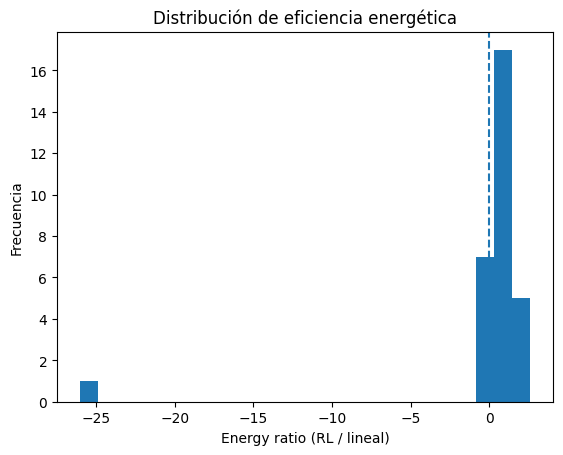

{'reward': 51.34400547721713, 'success': 0.4666666666666667, 'length': 188.26666666666668, 'energy_rl': 22.08204924163778, 'energy_linear': 21.85457794563022, 'energy_ratio': -0.019993531142780605, 'efficiency': 0.5538465270960025}


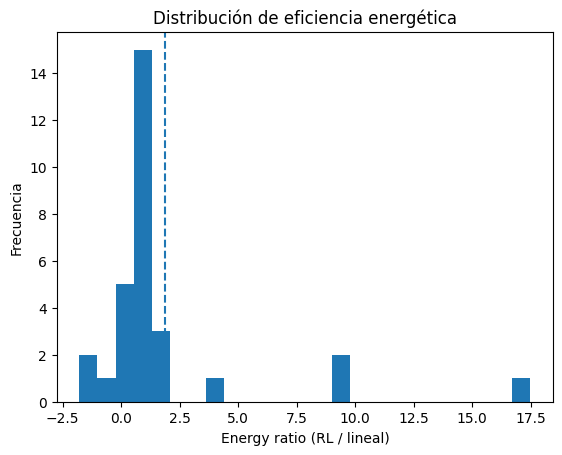

{'reward': 77.59045473212562, 'success': 0.6666666666666666, 'length': 152.03333333333333, 'energy_rl': 21.01908404092826, 'energy_linear': 23.32589222505945, 'energy_ratio': 1.8710847127181234, 'efficiency': 0.7169537176631807}


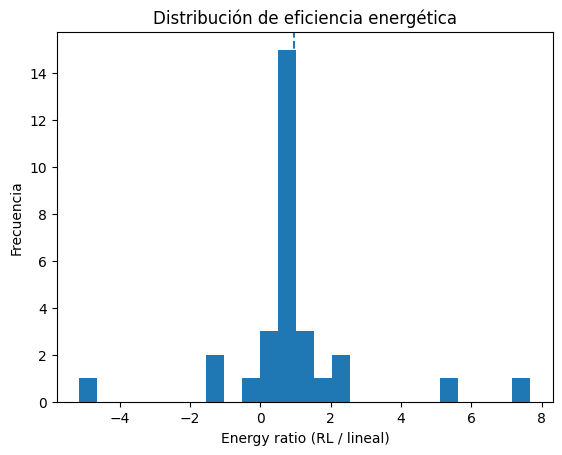

{'reward': 91.74542603784201, 'success': 0.7666666666666667, 'length': 130.53333333333333, 'energy_rl': -2.0855248079352093, 'energy_linear': -2.352929484118794, 'energy_ratio': 0.9586301524230699, 'efficiency': 0.7594045833871389}


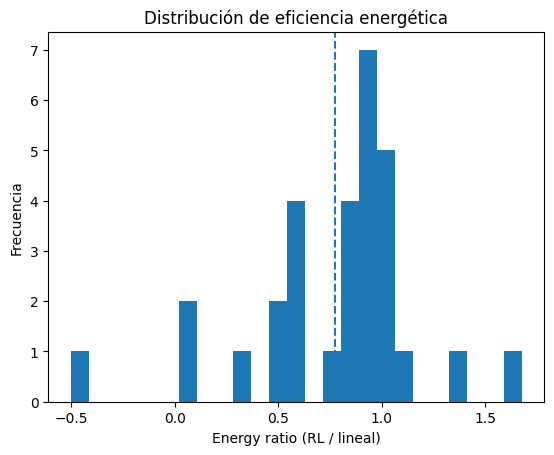

{'reward': 86.55532490347855, 'success': 0.6333333333333333, 'length': 149.33333333333334, 'energy_rl': 25.45549884370671, 'energy_linear': 30.558281918984434, 'energy_ratio': 0.7728338876291775, 'efficiency': 0.732128693876575}


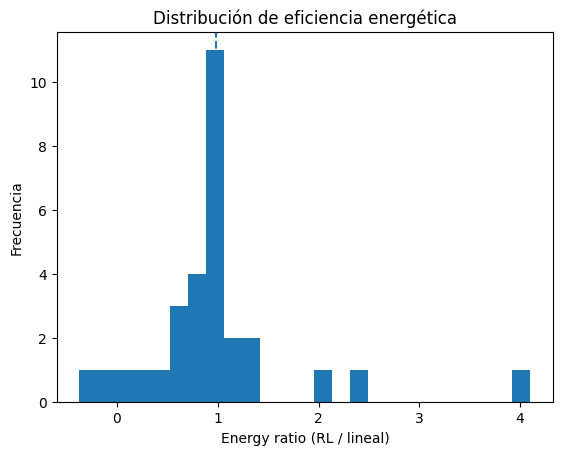

{'reward': 63.38797203039085, 'success': 0.5333333333333333, 'length': 160.63333333333333, 'energy_rl': 23.03786600824088, 'energy_linear': 24.784105078744346, 'energy_ratio': 0.9864238655761778, 'efficiency': 0.7237463915771056}


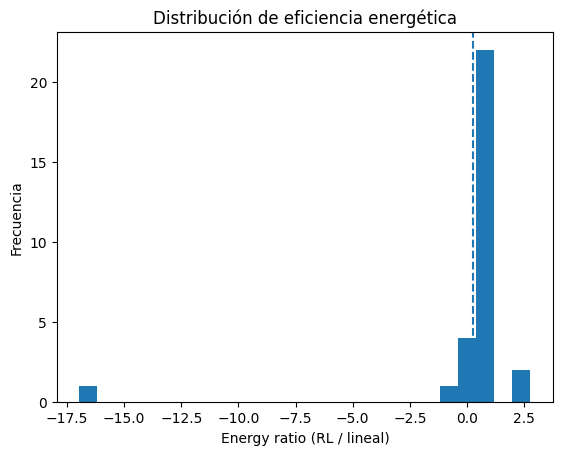

{'reward': 89.75620088690408, 'success': 0.8, 'length': 119.8, 'energy_rl': 20.607179977475116, 'energy_linear': 18.13399353248484, 'energy_ratio': 0.2701991785838946, 'efficiency': 0.839857892343928}


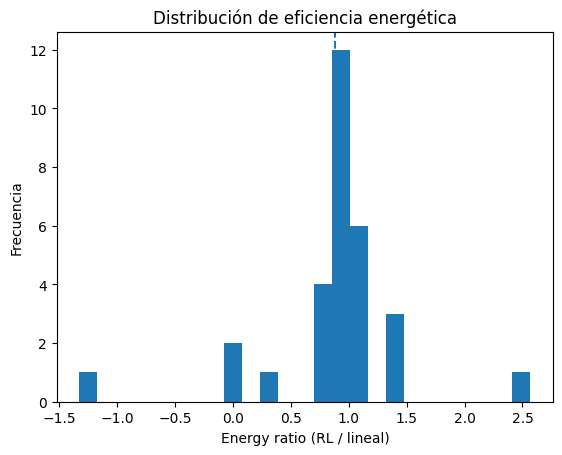

{'reward': 106.79542187279047, 'success': 0.8333333333333334, 'length': 124.06666666666666, 'energy_rl': 8.123242507654577, 'energy_linear': 13.199028021286376, 'energy_ratio': 0.8817813878492713, 'efficiency': 0.8599111786166084}


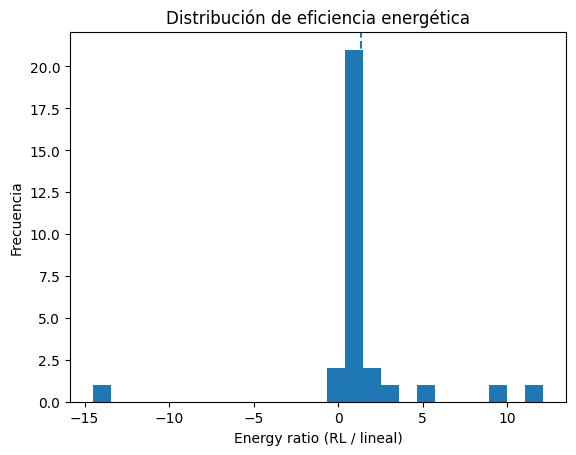

{'reward': 96.40316559742135, 'success': 0.7666666666666667, 'length': 128.2, 'energy_rl': 21.787089382863442, 'energy_linear': 25.602755322024006, 'energy_ratio': 1.330699647820934, 'efficiency': 0.7887740500656963}


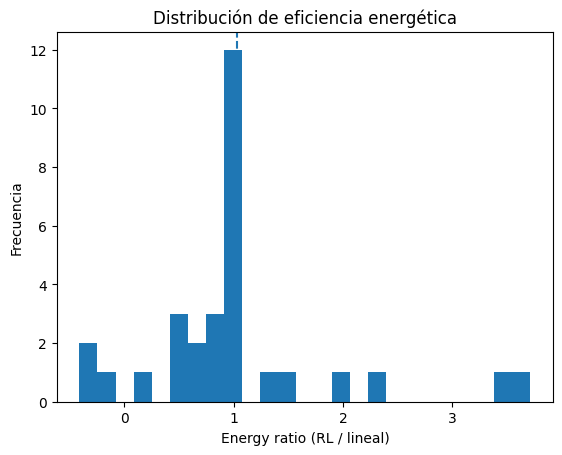

{'reward': 101.70328963306793, 'success': 0.8, 'length': 122.63333333333334, 'energy_rl': 25.80209347265402, 'energy_linear': 21.35198517100022, 'energy_ratio': 1.0261178486486702, 'efficiency': 0.8255235489871748}


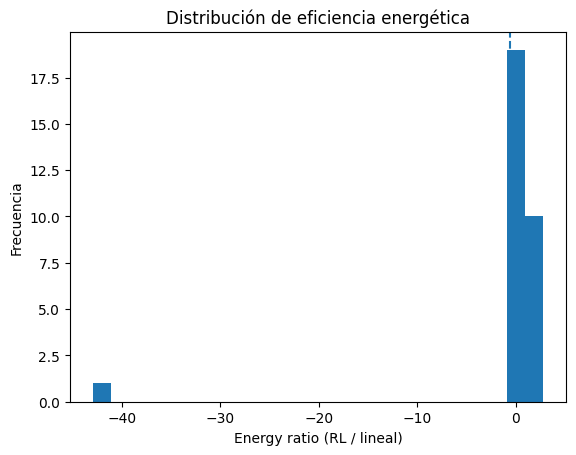

{'reward': 96.2272946025389, 'success': 0.8333333333333334, 'length': 115.46666666666667, 'energy_rl': 13.638441249582412, 'energy_linear': 14.14729984229981, 'energy_ratio': -0.5524092586548524, 'efficiency': 0.8448677817995551}


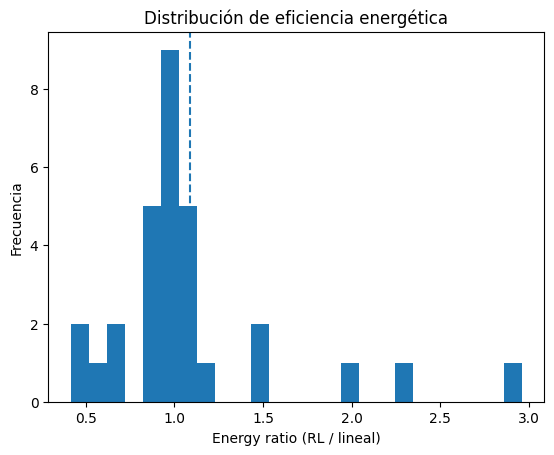

{'reward': 92.64591524678121, 'success': 0.6333333333333333, 'length': 148.66666666666666, 'energy_rl': 40.389872409718166, 'energy_linear': 37.11879077391573, 'energy_ratio': 1.0865896212122625, 'efficiency': 0.7399100492170182}


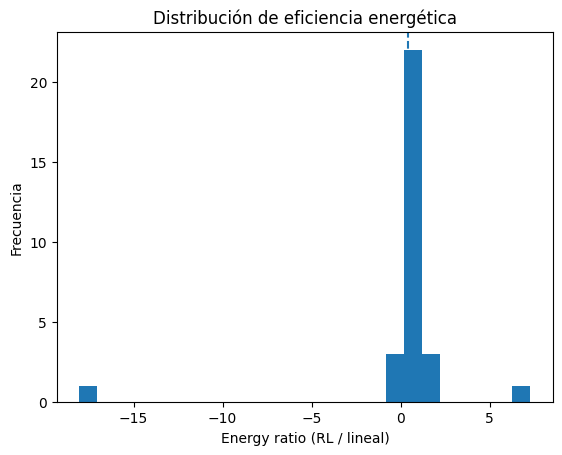

{'reward': 93.41232479092925, 'success': 0.7666666666666667, 'length': 130.9, 'energy_rl': 0.6891033236114649, 'energy_linear': 14.791233447947288, 'energy_ratio': 0.42157008711962785, 'efficiency': 0.8071696694063576}


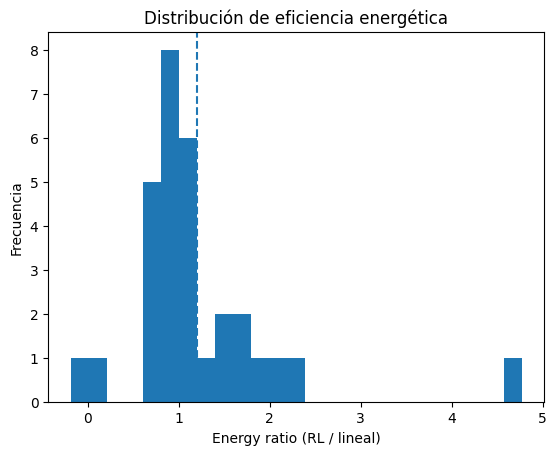

{'reward': 90.41282340352531, 'success': 0.6333333333333333, 'length': 145.13333333333333, 'energy_rl': 21.174000431984584, 'energy_linear': 15.422415252024626, 'energy_ratio': 1.1952958880186801, 'efficiency': 0.7362682947534164}


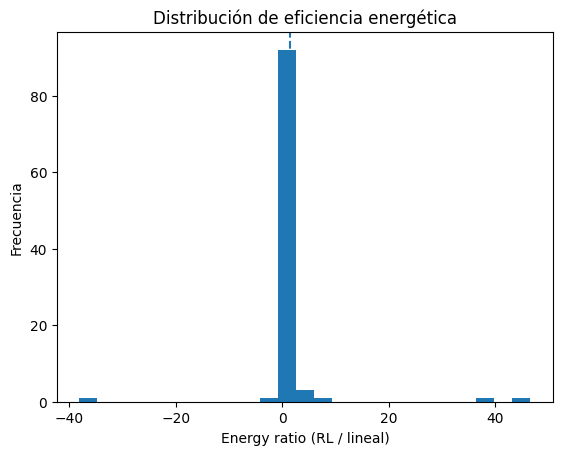


=== SAC ===
{'reward': 100.19909227451211, 'success': 0.72, 'length': 136.43, 'energy_rl': 20.0933235602818, 'energy_linear': 20.327235382798882, 'energy_ratio': 1.465460884639039, 'efficiency': 0.8058034586129714}


In [ ]:


# ====== Checkpoints ======
checkpoint_sac = CheckpointCallback(
    save_freq=50000,
    save_path="./models/sac_v2/",
    name_prefix="sac"
)

# ===================== SAC =====================
env_sac = DummyVecEnv([lambda: FastGradEnv()])

logger_sac = configure("./logs/SAC_v2/", ["tensorboard"])

#lr = 3e-4
# model_sac = SAC(
#     "MlpPolicy",
#     env_sac,
#     learning_rate=3e-4,
#     gamma=0.995,
#     batch_size=256,
#     ent_coef="auto",
#     verbose=0,
#     tensorboard_log=log_dir
# )

model_sac = SAC(
    "MlpPolicy",
    env_sac,
    learning_rate=1e-4,
    gamma=0.99,
    batch_size=512,
    tau=0.005,
    train_freq=(1, "step"),
    gradient_steps=1,
    ent_coef="auto_0.1",
    target_update_interval=1,
    learning_starts=10000,
    buffer_size=1_000_000,
    verbose=0,
)

model_sac.set_logger(logger_sac)

model_sac.learn(
    total_timesteps=800_000,
    tb_log_name="SAC",
    callback=[metrics_cb, checkpoint_sac]
    #,reset_num_timesteps=False
)

# ===================== EVALUACIÓN FINAL =====================
res_sac = evaluate2(model_sac, TestEnv(), n_episodes=100)

print("\n=== SAC ===")
print(res_sac)


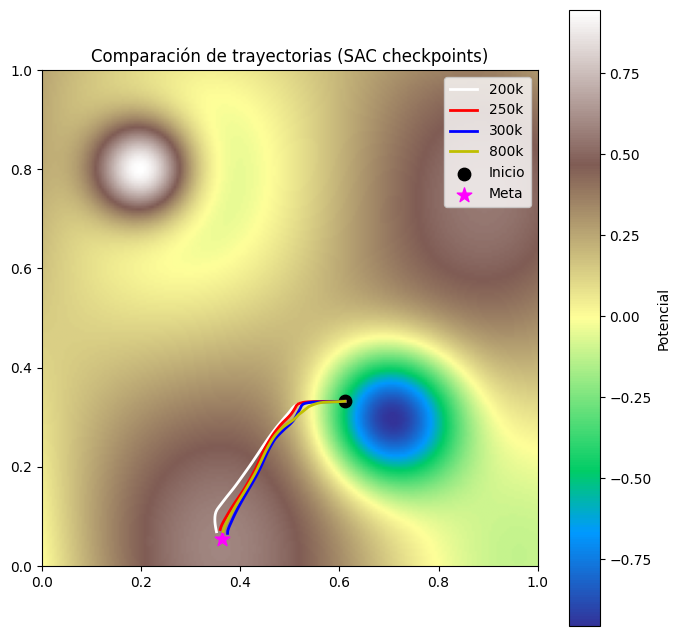

In [52]:
# ===== cargar modelos =====
modelo_sac = SAC.load('./models/sac_v1/sac_800000_steps.zip', env=TestEnv())
modelo_sac1 = SAC.load('./models/sac_v1/sac_650000_steps.zip', env=TestEnv())
modelo_sac2 = SAC.load('./models/sac_v1/sac_700000_steps.zip', env=TestEnv())
modelo_sac3 = SAC.load('./models/sac_v1/sac_750000_steps.zip', env=TestEnv())

modelos = {
    "200k": modelo_sac1,
    "250k": modelo_sac2,
    "300k": modelo_sac3,
    "800k": modelo_sac
}

# ===== crear entorno de test base =====
env_base = TestEnv()
obs, _ = env_base.reset()

start = env_base.pos.copy()
goal = env_base.goal.copy()

# ===== función para generar trayectoria =====
def get_traj(model, start, goal):
    env = TestEnv()
    obs, _ = env.reset()

    # fijar mismas condiciones
    env.pos = start.copy()
    env.goal = goal.copy()
    obs = env._obs()

    traj = [env.pos.copy()]
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, term, trunc, _ = env.step(action)
        traj.append(env.pos.copy())
        done = term or trunc

    return np.array(traj)


# ===== calcular trayectorias =====
traj_dict = {}
for name, model in modelos.items():
    traj_dict[name] = get_traj(model, start, goal)


# ===== mapa del potencial =====
res = 200
xs = np.linspace(0, 1, res)
ys = np.linspace(0, 1, res)
X, Y = np.meshgrid(xs, ys)

Z = np.zeros_like(X)
for i in range(res):
    for j in range(res):
        Z[i, j] = env_base.V_fn(X[i, j], Y[i, j])


# ===== plot =====
plt.figure(figsize=(8,8))
plt.imshow(Z, origin="lower", extent=[0,1,0,1], cmap="terrain")
plt.colorbar(label="Potencial")

# colores distintos
colors = ["w", "r", "b", "y", "g"]

for (name, traj), c in zip(traj_dict.items(), colors):
    plt.plot(traj[:,0], traj[:,1], c+"-", linewidth=2, label=name)

plt.scatter(start[0], start[1], c="black", s=80, label="Inicio")
plt.scatter(goal[0], goal[1], c="magenta", s=120, marker="*", label="Meta")

plt.legend()
plt.title("Comparación de trayectorias (SAC checkpoints)")
plt.show()

modelo 0
{'reward': 92.80592227990876, 'success': 0.78, 'length': 125.18, 'energy_rl': 19.257502593492173, 'energy_linear': 22.925679990637594, 'energy_ratio': 0.8396158392203933, 'efficiency': 0.8270901080867707}
modelo 1
{'reward': 80.2810261286303, 'success': 0.64, 'length': 144.48, 'energy_rl': 20.7425647539465, 'energy_linear': 25.442282922082722, 'energy_ratio': 1.114069395044786, 'efficiency': 0.7689417006255682}
modelo 2
{'reward': 87.08533503468055, 'success': 0.68, 'length': 141.54, 'energy_rl': 22.47541905922302, 'energy_linear': 21.09014203271684, 'energy_ratio': 0.8935731363738937, 'efficiency': 0.7549412840359848}
modelo 3
{'reward': 95.1588869002605, 'success': 0.78, 'length': 127.8, 'energy_rl': 22.637842246481647, 'energy_linear': 21.625190191884013, 'energy_ratio': 1.274965468188077, 'efficiency': 0.7862434520054665}


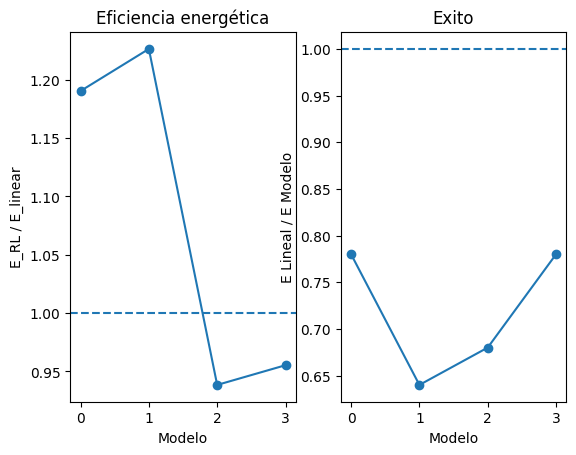

In [53]:
mods = [modelo_sac1, modelo_sac2, modelo_sac3, modelo_sac]
eff = np.zeros(4)
exito = np.zeros_like(eff)

fig, ax = plt.subplots(1, 2)

for i, modelo in enumerate(mods):
    print(f'modelo {i}')
    resultados = evaluate2(modelo, TestEnv(), n_episodes=50, plot_hist=False)
    print(resultados)

    eff[i] =  resultados['energy_linear']/resultados['energy_rl']
    exito[i] = resultados['success']

ax[0].plot(eff, marker='o')
ax[0].axhline(1, linestyle='--')  # baseline (trayectoria lineal)
ax[0].set_title("Eficiencia energética")
ax[0].set_xlabel("Modelo")
ax[0].set_ylabel("E_RL / E_linear")


ax[1].plot(exito, marker='o')
ax[1].axhline(1, linestyle='--')  # baseline (trayectoria lineal)
ax[1].set_title("Exito")
ax[1].set_xlabel("Modelo")
ax[1].set_ylabel("E Lineal / E Modelo")

plt.show()